# Movie Recommendation System

## Project Overview
This notebook builds a **content-based movie recommender** using the **TMDB 5000** dataset. Recommendations are generated by comparing movies based on textual metadata (overview, genres, cast, crew, keywords).

## Key Features
- End-to-end pipeline: loading → EDA → preprocessing → vectorization → similarity computation
- Content-based recommendations using cosine similarity
- Export of artifacts (`movie_list.pkl`, `similarity.pkl`) for reuse in an application

## Tech Stack Used
- Python, NumPy, Pandas
- Scikit-learn (CountVectorizer, cosine similarity)
- NLTK (stemming)
- Matplotlib & Seaborn (visualizations)


## Data Loading

Load the TMDB movies and credits datasets into pandas DataFrames for exploration and processing.


In [1]:
import numpy as np
import pandas as pd
import ast


In [2]:
# Load datasets (movies metadata + credits)
movies = pd.read_csv('../data/tmdb_5000_movies.csv')
credits = pd.read_csv('../data/tmdb_5000_credits.csv')

In [3]:
movies.head()


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [4]:
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [5]:
credits.head()['cast'].values

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

## EDA

Quick exploratory analysis *before* cleaning/feature engineering.

We focus on popularity, rating distribution, and the budget - revenue relationship.


### Full EDA Report
This section explores the dataset's content signals (genres, ratings, directors) and behavioral/market signals (popularity, budget/revenue, release patterns). Understanding these distributions helps us validate data quality and anticipate how the recommendation model may behave.


### EDA Setup
We set a consistent visual style to keep the report readable and professional.


In [6]:
# EDA imports & styling
import ast
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


### Popularity Analysis (Top 10 Most Popular Movies)
This chart highlights the most *popular* movies in the dataset. Popularity is a useful diagnostic because highly popular titles often dominate user attention, and they can become frequent recommendation anchors if popularity-related features leak into modeling decisions.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2468\4006802033.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pop, x='popularity', y='title', palette=sns.color_palette('rocket', n_colors=len(top_pop)))


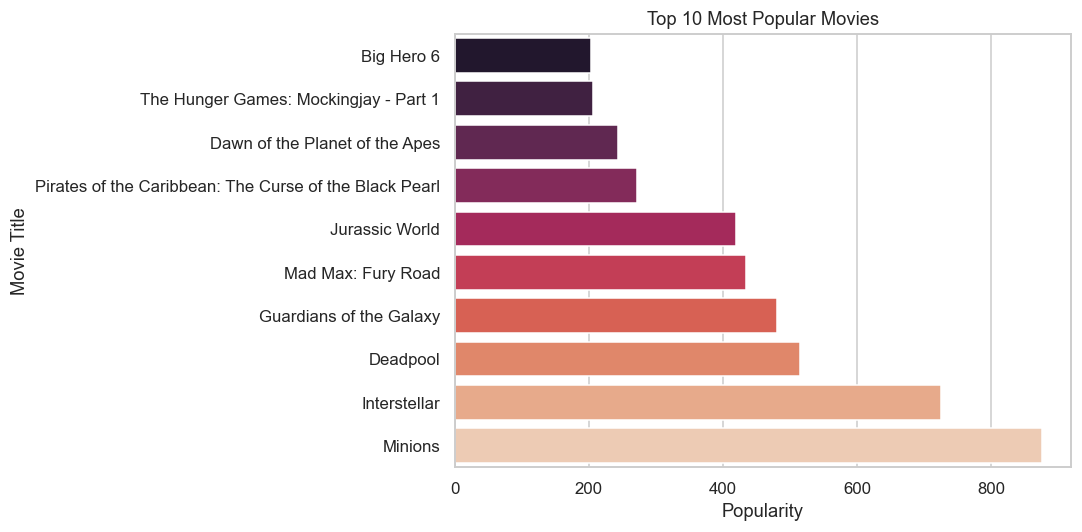

In [7]:
# Horizontal bar chart: Top 10 most popular movies
top_pop = movies[['title', 'popularity']].copy()
top_pop['popularity'] = pd.to_numeric(top_pop['popularity'], errors='coerce')
top_pop = top_pop.dropna().sort_values('popularity', ascending=False).head(10)
top_pop = top_pop.sort_values('popularity', ascending=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_pop, x='popularity', y='title', palette=sns.color_palette('rocket', n_colors=len(top_pop)))
plt.title('Top 10 Most Popular Movies')
plt.xlabel('Popularity')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()


### Genre Analysis (Top 10 Genres)
This bar chart shows which genres appear most frequently across movies. Genres are a key content signal for content-based recommendation—a skew toward certain genres can lead to denser similarity clusters and biased recommendation exposure.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2468\665483388.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_df, x='count', y='genre', palette=sns.color_palette('viridis', n_colors=len(genre_df)))


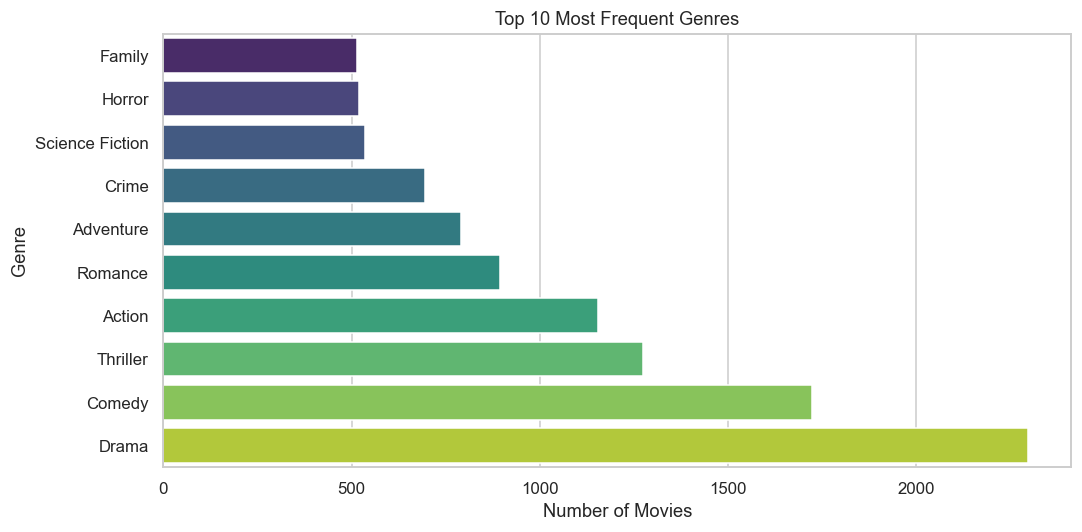

In [8]:
# Bar chart: Top 10 most frequent genres (without mutating `movies`)
genres_raw = movies['genres'].dropna()
genres_parsed = genres_raw.apply(ast.literal_eval)

all_genres = [g.get('name') for lst in genres_parsed for g in lst if isinstance(g, dict)]
all_genres = [g for g in all_genres if g]

top_genres = Counter(all_genres).most_common(10)
genre_df = pd.DataFrame(top_genres, columns=['genre', 'count']).sort_values('count', ascending=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=genre_df, x='count', y='genre', palette=sns.color_palette('viridis', n_colors=len(genre_df)))
plt.title('Top 10 Most Frequent Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()


### Financial Correlation (Budget vs Revenue)
This scatter plot (with a regression trend line) highlights how production budget relates to revenue. Financial scale often correlates with marketing reach and audience size, which can indirectly affect popularity-driven signals used in recommendations.


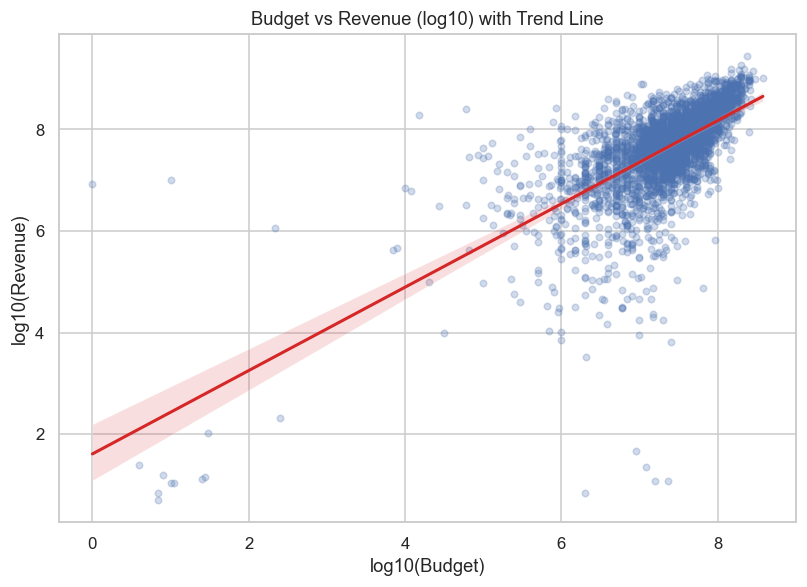

In [9]:
# Scatter + regression: Budget vs Revenue (log10 transform for interpretability)
fin = movies[['budget', 'revenue']].copy()
fin['budget'] = pd.to_numeric(fin['budget'], errors='coerce')
fin['revenue'] = pd.to_numeric(fin['revenue'], errors='coerce')
fin = fin.dropna()
fin = fin[(fin['budget'] > 0) & (fin['revenue'] > 0)]

fin['log_budget'] = np.log10(fin['budget'])
fin['log_revenue'] = np.log10(fin['revenue'])

plt.figure(figsize=(7.5, 5.5))
sns.regplot(
    data=fin, x='log_budget', y='log_revenue',
    scatter_kws={'alpha': 0.25, 's': 18},
    line_kws={'color': '#d62728', 'lw': 2}
)
plt.title('Budget vs Revenue (log10) with Trend Line')
plt.xlabel('log10(Budget)')
plt.ylabel('log10(Revenue)')
plt.tight_layout()
plt.show()


### Rating Distribution (vote_average)
This histogram with a KDE curve shows how users generally rate movies. The rating distribution helps us understand whether the dataset is dominated by mid-rated content and whether ratings might be useful as a filtering/weighting signal in recommendations.


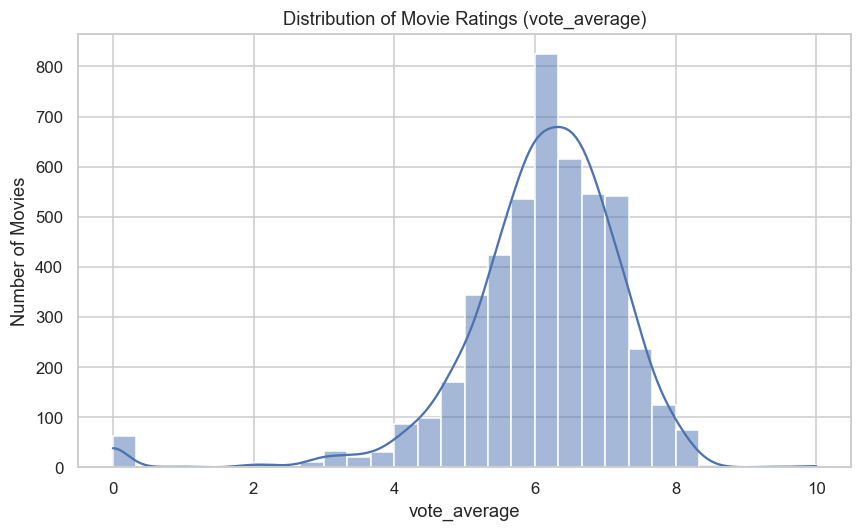

In [10]:
# Histogram + KDE: vote_average
ratings = movies['vote_average'].dropna()

plt.figure(figsize=(8, 5))
sns.histplot(ratings, bins=30, kde=True, color=sns.color_palette('deep')[0])
plt.title('Distribution of Movie Ratings (vote_average)')
plt.xlabel('vote_average')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()


### Movie Release Trends (Movies per Year)
This line chart shows how many movies were released each year in the dataset. Release trends matter because temporal effects (older vs newer content) can influence popularity, rating patterns, and the diversity of recommendations.


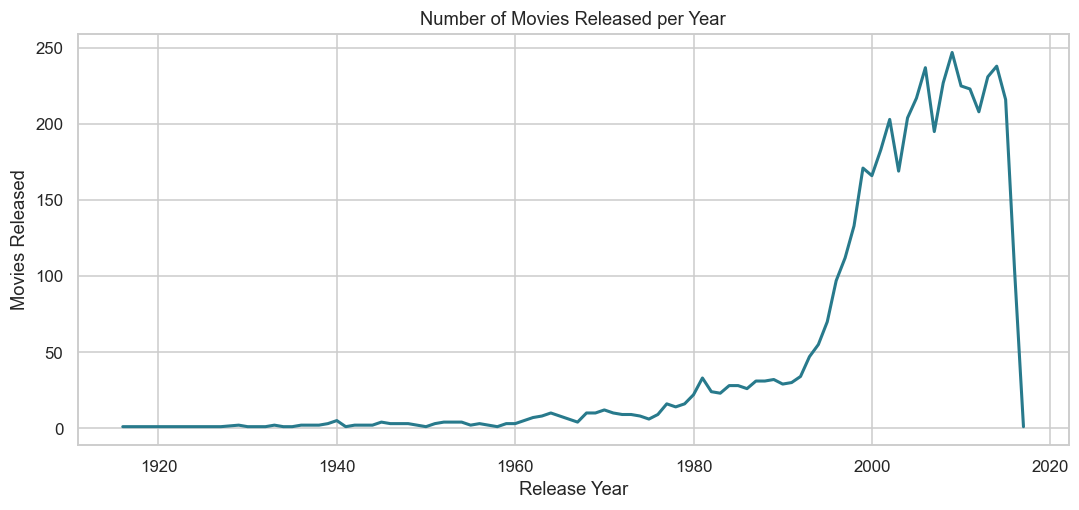

In [11]:
# Line chart: number of movies released per year
release_dt = pd.to_datetime(movies['release_date'], errors='coerce')
release_year = release_dt.dt.year

year_counts = release_year.dropna().astype(int).value_counts().sort_index()

# Keep a reasonable range (optional safeguard against bad dates)
year_counts = year_counts[(year_counts.index >= 1900) & (year_counts.index <= 2030)]

plt.figure(figsize=(10, 4.8))
sns.lineplot(x=year_counts.index, y=year_counts.values, color=sns.color_palette('crest')[3], lw=2)
plt.title('Number of Movies Released per Year')
plt.xlabel('Release Year')
plt.ylabel('Movies Released')
plt.tight_layout()
plt.show()


### Top Directors (Most Movies in Dataset)
This chart shows directors who appear most frequently in the dataset. Directors can be a strong creative signal—people often prefer movies with similar directing styles—so understanding director coverage helps gauge how useful this feature may be for recommendations.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2468\1583613415.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dir_df, x='count', y='director', palette=sns.color_palette('mako', n_colors=len(dir_df)))


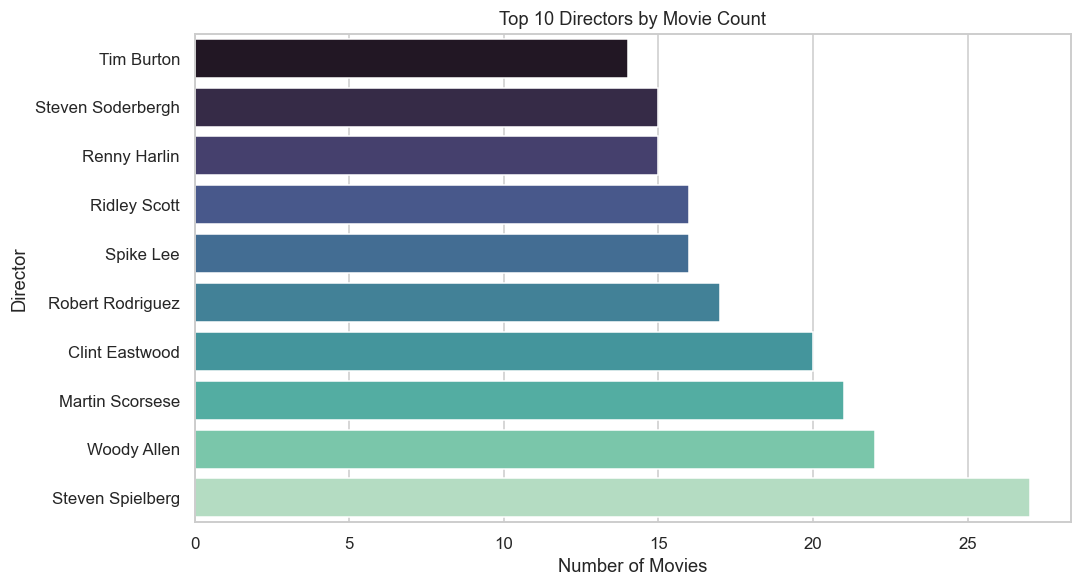

In [12]:
# Bar chart: Top 10 directors by number of movies (parse from `credits['crew']`)
crew_raw = credits['crew'].dropna()
crew_parsed = crew_raw.apply(ast.literal_eval)

directors = []
for crew_list in crew_parsed:
    if not isinstance(crew_list, list):
        continue
    for member in crew_list:
        if isinstance(member, dict) and member.get('job') == 'Director':
            name = member.get('name')
            if name:
                directors.append(name)

top_directors = Counter(directors).most_common(10)
dir_df = pd.DataFrame(top_directors, columns=['director', 'count']).sort_values('count', ascending=True)

plt.figure(figsize=(10, 5.5))
sns.barplot(data=dir_df, x='count', y='director', palette=sns.color_palette('mako', n_colors=len(dir_df)))
plt.title('Top 10 Directors by Movie Count')
plt.xlabel('Number of Movies')
plt.ylabel('Director')
plt.tight_layout()
plt.show()


## Preprocessing

Clean missing values, parse JSON-like columns (genres, keywords, cast, crew), and build a combined text feature (tags).


In [13]:
# Merge credits into movies (join on 'title')
movies = movies.merge(credits,on='title')

In [14]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [15]:
# geners
# id
# keywords
# overview
# cost
# crew

movies = movies[['movie_id','title','overview','genres','keywords','cast','crew']]

In [16]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  4809 non-null   int64
 1   title     4809 non-null   str  
 2   overview  4806 non-null   str  
 3   genres    4809 non-null   str  
 4   keywords  4809 non-null   str  
 5   cast      4809 non-null   str  
 6   crew      4809 non-null   str  
dtypes: int64(1), str(6)
memory usage: 263.1 KB


In [17]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [18]:
movies.isnull().sum()

movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [19]:
# Drop rows with missing values to simplify downstream parsing
movies.dropna(inplace=True)

In [20]:
movies.duplicated().sum()

np.int64(0)

In [21]:
movies.iloc[0].genres

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [22]:
# '[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'
# ['Action','Adventure','Fantacy,'Science Fiction']

In [23]:
# Convert a JSON-like string column into a list of names
def convert(obj):
    L = []
    for i in ast.literal_eval(obj):
        L.append(i['name'])
    return L

In [24]:
movies['genres'].apply(convert)


0       [Action, Adventure, Fantasy, Science Fiction]
1                        [Adventure, Fantasy, Action]
2                          [Action, Adventure, Crime]
3                    [Action, Crime, Drama, Thriller]
4                [Action, Adventure, Science Fiction]
                            ...                      
4804                        [Action, Crime, Thriller]
4805                                [Comedy, Romance]
4806               [Comedy, Drama, Romance, TV Movie]
4807                                               []
4808                                    [Documentary]
Name: genres, Length: 4806, dtype: object

In [25]:
# Parse genres into a list of genre names
movies['genres'] = movies['genres'].apply(convert)

In [26]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [27]:
# Parse keywords into a list of keyword strings
movies['keywords'] = movies['keywords'].apply(convert)

In [28]:
# Extract top 3 cast member names from the cast field
def convert3(obj):
    if isinstance(obj, list):
        items = obj
    else:
        items = ast.literal_eval(obj)
    
    L = []
    for i in items[:3]:
        L.append(i['name'])
    return L

def convert3(obj):
    if isinstance(obj, str):
        try:
            items = ast.literal_eval(obj)
        except (ValueError, SyntaxError):
            return []
    elif isinstance(obj, list):
        items = obj
    else:
        return []

    L = []
    for i in items[:3]:
        if isinstance(i, dict) and 'name' in i:
            L.append(i['name'])
        elif isinstance(i, str):
            L.append(i)
    return L

movies['cast'] = movies['cast'].apply(convert3)

In [29]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [30]:
movies['crew'][0]

'[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"},

In [31]:
# Extract the director name from the crew field
def fetch_director(obj):
    L = []
    for i in ast.literal_eval(obj):
        if i['job'] == 'Director':
            L.append(i['name'])
            break
    return L

In [32]:
# Keep director as an important signal
movies['crew'] = movies['crew'].apply(fetch_director)

In [33]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


In [34]:
movies['overview'][0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [35]:
# Tokenize overview text into word tokens
movies['overview'] = movies['overview'].apply(lambda x:x.split())

In [36]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


In [37]:
# Remove spaces within multi-word tokens (e.g., "Science Fiction" -> "ScienceFiction")
movies['genres'] = movies['genres'].apply(lambda x: [i.replace(" ","") for i in x])
movies['keywords'] = movies['keywords'].apply(lambda x: [i.replace(" ","") for i in x]) 
movies['cast'] = movies['cast'].apply(lambda x: [i.replace(" ","") for i in x])
movies['crew'] = movies['crew'].apply(lambda x: [i.replace(" ","") for i in x])

In [38]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron]
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski]
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes]
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan]
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton]


In [39]:
# Combine multiple text sources into a single tags field
movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

In [40]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron],"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski],"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes],"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan],"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton],"[John, Carter, is, a, war-weary,, former, mili..."


In [41]:
# Keep only the columns needed for recommendations
new_df = movies[['movie_id','title','tags']]

In [42]:
# Join token lists into a single space-separated string
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x))

In [43]:
new_df.head()

,movie_id,title,tags
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...
4,49529,John Carter,"John Carter is a war-weary, former military ca..."


In [44]:
new_df['tags'][0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. Action Adventure Fantasy ScienceFiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d SamWorthington ZoeSaldana SigourneyWeaver JamesCameron'

In [45]:
# Normalize case
new_df['tags'] = new_df['tags'].apply(lambda x:x.lower())

In [46]:
new_df.head()

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


In [47]:
# NLP utilities for stemming
import nltk

In [48]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [49]:
# Stem tokens to reduce sparsity (e.g., loving -> love)
def stem(text):
    y = []
    for i in text.split():
        y.append(ps.stem(i))
        
    return " ".join(y)

In [50]:
# Apply stemming to reduce vocabulary size
new_df['tags'] = new_df['tags'].apply(stem)

In [51]:
new_df['tags'][1]

"captain barbossa, long believ to be dead, ha come back to life and is head to the edg of the earth with will turner and elizabeth swann. but noth is quit as it seems. adventur fantasi action ocean drugabus exoticisland eastindiatradingcompani loveofone'slif traitor shipwreck strongwoman ship allianc calypso afterlif fighter pirat swashbuckl aftercreditssting johnnydepp orlandobloom keiraknightley goreverbinski"

## Vectorization

Convert the text tags into numerical vectors using a bag-of-words representation (CountVectorizer).


In [52]:
# Vectorize tags into bag-of-words features
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000, stop_words='english')


In [53]:
# Fit vectorizer on tags and transform to dense vectors
vectors = cv.fit_transform(new_df['tags']).toarray()

In [54]:
vectors

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4806, 5000))

In [55]:
vectors[0]

array([0, 0, 0, ..., 0, 0, 0], shape=(5000,))

In [56]:
cv.get_feature_names_out()

array(['000', '007', '10', ..., 'zone', 'zoo', 'zooeydeschanel'],
      shape=(5000,), dtype=object)

In [57]:
['love''loving','loved']
['love','love','love']

['love', 'love', 'love']

In [58]:
ps.stem('loving')

'love'

In [59]:
stem('captain barbossa, long believed to be dead, has come back to life and is headed to the edge of the earth with will turner and elizabeth swann. but nothing is quite as it seems. adventure fantasy action ocean drugabuse exoticisland eastindiatradingcompany loveofone\'slife traitor shipwreck strongwoman ship alliance calypso afterlife fighter pirate swashbuckler aftercreditsstinger johnnydepp orlandobloom keiraknightley goreverbinski')

"captain barbossa, long believ to be dead, ha come back to life and is head to the edg of the earth with will turner and elizabeth swann. but noth is quit as it seems. adventur fantasi action ocean drugabus exoticisland eastindiatradingcompani loveofone'slif traitor shipwreck strongwoman ship allianc calypso afterlif fighter pirat swashbuckl aftercreditssting johnnydepp orlandobloom keiraknightley goreverbinski"

## Similarity Matrix

Compute cosine similarity between movie vectors to quantify how similar two movies are based on their tags.


In [60]:
# Compute pairwise cosine similarity between all movie vectors
from sklearn.metrics.pairwise import cosine_similarity


In [61]:
# Compute pairwise cosine similarity between all movie vectors
similarity = cosine_similarity(vectors)

In [62]:
sorted(enumerate(similarity[0]), reverse=True, key=lambda x: x[1])[1:6]

[(1214, np.float64(0.28676966733820225)),
 (2405, np.float64(0.26901379342448517)),
 (3728, np.float64(0.2605130246476754)),
 (507, np.float64(0.255608593705383)),
 (539, np.float64(0.25038669783359574))]

## Recommendation Function

Given a movie title, retrieve the most similar movies using the precomputed similarity matrix.


In [63]:
# Recommend top similar movies for a given title
def recommend(movie):
    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[movie_index]
    movies_list = sorted(list(enumerate(distances)),reverse=True,key=lambda x:x[1])[1:6]
    
    for i in movies_list:
        print(new_df.iloc[i[0]].title)

In [64]:
recommend('Avatar')

Aliens vs Predator: Requiem
Aliens
Falcon Rising
Independence Day
Titan A.E.


In [65]:
new_df.iloc[0].title

'Avatar'

## Exporting Model

Export the processed movie list and similarity matrix so they can be loaded later (e.g., in a web app).


In [66]:
# Export artifacts for the web app
import pickle
from pathlib import Path

# Save into web_app\models (relative to the notebooks folder)
models_dir = Path('..') / 'web_app' / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

pickle.dump(new_df.to_dict(), open(models_dir / 'movie_list.pkl', 'wb'))
pickle.dump(similarity, open(models_dir / 'similarity.pkl', 'wb'))

print('Saved:', (models_dir / 'movie_list.pkl').resolve())
print('Saved:', (models_dir / 'similarity.pkl').resolve())


Saved: D:\Internship\Movie_Recommendation_System\web_app\models\movie_list.pkl
Saved: D:\Internship\Movie_Recommendation_System\web_app\models\similarity.pkl
